# Assignment 1: Student Performance Prediction Using ANN

## Objective
Predict the **Final Grade** of students using an Artificial Neural Network (ANN).

**Dataset:** 300K Student Performance Prediction Dataset

### Assignment Requirements
- Data loading and basic EDA
- Missing-value and duplicate handling
- Categorical encoding
- Feature scaling
- Train/test split
- Multiple ANN architectures
- At least 3 activation-function configurations
- At least 3 optimizers
- Different epochs and batch sizes
- Loss and validation-loss observation
- Test-set prediction
- Model comparison
- Best-model selection
- Short conclusion

> **Important:** `final_grade` is the target. `student_id` is an identifier. `grade_category` and `pass_fail` are excluded from X because they are target-derived variables and can cause data leakage.


In [1]:
# If TensorFlow is not installed, uncomment and run the next line:
# !pip install tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)


ModuleNotFoundError: No module named 'tensorflow'

In [2]:
# 1. Load Dataset

file_path = "student_performance_prediction_dataset-2.csv"
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
display(df.head())


Dataset Shape: (300000, 25)


,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
0,1,21,Male,1.645404,79.154521,8.230886,96.053840,7.719620,1.871170,1.447894,...,4.018412,Medium,Master,Yes,Mobile,Private,Coding Club,59.248749,D,Pass
1,2,18,Male,4.462126,72.526685,6.139219,53.024821,6.754758,5.630071,1.891288,...,3.268642,Medium,Master,Yes,Laptop,Public,NaN,58.595595,D,Pass
2,3,19,Female,6.220212,98.531716,6.946313,78.775422,10.000000,7.862877,1.774356,...,2.327293,Low,High School,Yes,Tablet,Private,Music,85.855289,A,Pass
3,4,21,Female,1.826644,97.731245,8.297048,76.122618,7.440486,2.316252,1.204271,...,1.163367,Medium,Bachelor,Yes,Laptop,Public,Debate,42.117503,F,Fail
4,5,17,Male,3.789322,78.589107,6.777171,81.305681,9.962609,5.335697,1.399230,...,0.411183,High,High School,Yes,Laptop,Private,Debate,62.870474,C,Pass


In [3]:
# 2. Basic EDA

print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()


Column Names:
['student_id', 'age', 'gender', 'study_hours', 'attendance', 'sleep_hours', 'previous_grade', 'assignments_completed', 'practice_tests_taken', 'group_study_hours', 'notes_quality_score', 'time_management_score', 'motivation_level', 'mental_health_score', 'screen_time', 'social_media_hours', 'family_income', 'parent_education', 'internet_access', 'device_type', 'school_type', 'extracurriculars', 'final_grade', 'grade_category', 'pass_fail']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   student_id             300000 non-null  int64  
 1   age                    300000 non-null  int64  
 2   gender                 300000 non-null  object 
 3   study_hours            300000 non-null  float64
 4   attendance             300000 non-null  float64
 5   sleep_hours            300000 non

In [4]:
# 3. Statistical Summary

display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,300000.0,NaN,NaN,NaN,150000.5,86602.684716,1.0,75000.75,150000.5,225000.25,300000.0
age,300000.0,NaN,NaN,NaN,17.99907,1.999235,15.0,16.0,18.0,20.0,21.0
gender,300000,3,Female,144083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours,300000.0,NaN,NaN,NaN,4.503062,1.978513,0.0,3.143566,4.498272,5.843646,12.0
attendance,300000.0,NaN,NaN,NaN,84.699395,9.41945,40.0,78.241008,84.990371,91.732244,100.0
sleep_hours,300000.0,NaN,NaN,NaN,6.991431,1.46307,3.0,5.992666,6.999011,8.013284,10.0
previous_grade,300000.0,NaN,NaN,NaN,69.840184,14.683157,20.0,59.870863,69.955736,80.102857,100.0
assignments_completed,300000.0,NaN,NaN,NaN,7.836044,1.732474,0.0,6.654817,8.000829,9.357154,10.0
practice_tests_taken,300000.0,NaN,NaN,NaN,4.017508,1.956444,0.0,2.655243,4.001981,5.349494,10.0
group_study_hours,300000.0,NaN,NaN,NaN,1.529057,0.941525,0.0,0.826462,1.499206,2.17268,5.840593


In [5]:
# 4. Missing Values

missing = df.isnull().sum()
missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": (missing / len(df) * 100).round(2)
})

display(missing_table[missing_table["Missing Values"] > 0])

print("Total missing values:", df.isnull().sum().sum())


,Missing Values,Missing Percentage
device_type,15105,5.04
extracurriculars,49981,16.66
grade_category,4,0.00


Total missing values: 65090


In [6]:
# 5. Duplicate Values

print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


Target column: final_grade


count    300000.000000
mean         53.089206
std          12.225161
min           0.000000
25%          44.867737
50%          53.167495
75%          61.379373
max         100.000000
Name: final_grade, dtype: float64

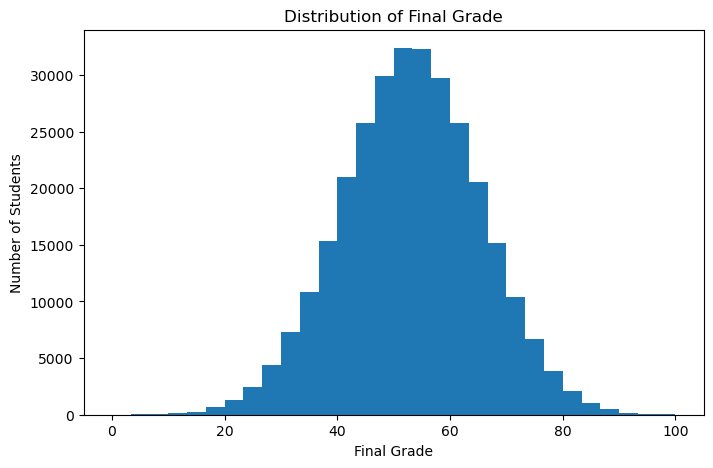

In [7]:
# 6. Target Variable

print("Target column: final_grade")
display(df["final_grade"].describe())

plt.figure(figsize=(8,5))
plt.hist(df["final_grade"], bins=30)
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grade")
plt.show()


In [8]:
# 7. Separate Features (X) and Target (y)

# student_id = identifier, not a useful predictive feature
# grade_category and pass_fail = target-derived variables, removed to prevent data leakage

drop_columns = [
    "student_id",
    "final_grade",
    "grade_category",
    "pass_fail"
]

X = df.drop(columns=drop_columns)
y = df["final_grade"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nInput features:")
print(X.columns.tolist())


X shape: (300000, 21)
y shape: (300000,)

Input features:
['age', 'gender', 'study_hours', 'attendance', 'sleep_hours', 'previous_grade', 'assignments_completed', 'practice_tests_taken', 'group_study_hours', 'notes_quality_score', 'time_management_score', 'motivation_level', 'mental_health_score', 'screen_time', 'social_media_hours', 'family_income', 'parent_education', 'internet_access', 'device_type', 'school_type', 'extracurriculars']


In [9]:
# 8. Identify Numerical and Categorical Features

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


Numerical Features:
['age', 'study_hours', 'attendance', 'sleep_hours', 'previous_grade', 'assignments_completed', 'practice_tests_taken', 'group_study_hours', 'notes_quality_score', 'time_management_score', 'motivation_level', 'mental_health_score', 'screen_time', 'social_media_hours']

Categorical Features:
['gender', 'family_income', 'parent_education', 'internet_access', 'device_type', 'school_type', 'extracurriculars']


In [10]:
# 9. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (240000, 21)
Testing data: (60000, 21)


In [11]:
# 10. Preprocessing Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)


Processed training shape: (240000, 36)
Processed testing shape: (60000, 36)


In [12]:
# 11. ANN Model Function

def create_ann(input_dim, hidden_layers, activation, optimizer):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for neurons in hidden_layers:
        model.add(Dense(neurons, activation=activation))

    # Regression output: one continuous value
    model.add(Dense(1, activation="linear"))

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    return model


def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test, verbose=0).flatten()

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    return predictions, mae, mse, rmse, r2


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("ANN model function created.")


NameError: name 'EarlyStopping' is not defined

## Experiment 1 — ReLU + Adam

Architecture: **64 → 32**  
Optimizer: **Adam**  
Epochs: **50**  
Batch size: **256**


In [13]:
model1 = create_ann(
    input_dim=X_train_processed.shape[1],
    hidden_layers=[64, 32],
    activation="relu",
    optimizer="adam"
)

history1 = model1.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

pred1, mae1, mse1, rmse1, r2_1 = evaluate_model(
    model1, X_test_processed, y_test
)

print("\nModel 1 Results")
print("MAE :", mae1)
print("MSE :", mse1)
print("RMSE:", rmse1)
print("R2  :", r2_1)


NameError: name 'Sequential' is not defined

In [14]:
# Experiment 1: Training vs Validation Loss

plt.figure(figsize=(8,5))
plt.plot(history1.history["loss"], label="Training Loss")
plt.plot(history1.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Model 1 - ReLU + Adam")
plt.legend()
plt.show()


NameError: name 'history1' is not defined

<Figure size 800x500 with 0 Axes>

## Experiment 2 — Tanh + SGD

Architecture: **64 → 32**  
Optimizer: **SGD**  
Epochs: **50**  
Batch size: **256**


In [15]:
model2 = create_ann(
    input_dim=X_train_processed.shape[1],
    hidden_layers=[64, 32],
    activation="tanh",
    optimizer="sgd"
)

history2 = model2.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

pred2, mae2, mse2, rmse2, r2_2 = evaluate_model(
    model2, X_test_processed, y_test
)

print("\nModel 2 Results")
print("MAE :", mae2)
print("MSE :", mse2)
print("RMSE:", rmse2)
print("R2  :", r2_2)


NameError: name 'Sequential' is not defined

In [16]:
# Experiment 2: Training vs Validation Loss

plt.figure(figsize=(8,5))
plt.plot(history2.history["loss"], label="Training Loss")
plt.plot(history2.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Model 2 - Tanh + SGD")
plt.legend()
plt.show()


NameError: name 'history2' is not defined

<Figure size 800x500 with 0 Axes>

## Experiment 3 — ReLU + RMSprop

Architecture: **128 → 64 → 32**  
Optimizer: **RMSprop**  
Epochs: **100**  
Batch size: **256**


In [17]:
model3 = create_ann(
    input_dim=X_train_processed.shape[1],
    hidden_layers=[128, 64, 32],
    activation="relu",
    optimizer="rmsprop"
)

history3 = model3.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

pred3, mae3, mse3, rmse3, r2_3 = evaluate_model(
    model3, X_test_processed, y_test
)

print("\nModel 3 Results")
print("MAE :", mae3)
print("MSE :", mse3)
print("RMSE:", rmse3)
print("R2  :", r2_3)


NameError: name 'Sequential' is not defined

In [18]:
# Experiment 3: Training vs Validation Loss

plt.figure(figsize=(8,5))
plt.plot(history3.history["loss"], label="Training Loss")
plt.plot(history3.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Model 3 - ReLU + RMSprop")
plt.legend()
plt.show()


NameError: name 'history3' is not defined

<Figure size 800x500 with 0 Axes>

## Experiment 4 — Sigmoid + Adam

Architecture: **64 → 32**  
Optimizer: **Adam**  
Epochs: **50**  
Batch size: **256**


In [19]:
model4 = create_ann(
    input_dim=X_train_processed.shape[1],
    hidden_layers=[64, 32],
    activation="sigmoid",
    optimizer="adam"
)

history4 = model4.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

pred4, mae4, mse4, rmse4, r2_4 = evaluate_model(
    model4, X_test_processed, y_test
)

print("\nModel 4 Results")
print("MAE :", mae4)
print("MSE :", mse4)
print("RMSE:", rmse4)
print("R2  :", r2_4)


NameError: name 'Sequential' is not defined

In [20]:
# Experiment 4: Training vs Validation Loss

plt.figure(figsize=(8,5))
plt.plot(history4.history["loss"], label="Training Loss")
plt.plot(history4.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Model 4 - Sigmoid + Adam")
plt.legend()
plt.show()


NameError: name 'history4' is not defined

<Figure size 800x500 with 0 Axes>

## Experiment 5 — Deep ReLU + Adam

Architecture: **128 → 64 → 32 → 16**  
Optimizer: **Adam**  
Epochs: **100**  
Batch size: **256**

This experiment changes the number of hidden layers and neurons to satisfy the architecture-comparison requirement.


In [21]:
model5 = create_ann(
    input_dim=X_train_processed.shape[1],
    hidden_layers=[128, 64, 32, 16],
    activation="relu",
    optimizer="adam"
)

history5 = model5.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

pred5, mae5, mse5, rmse5, r2_5 = evaluate_model(
    model5, X_test_processed, y_test
)

print("\nModel 5 Results")
print("MAE :", mae5)
print("MSE :", mse5)
print("RMSE:", rmse5)
print("R2  :", r2_5)


NameError: name 'Sequential' is not defined

In [22]:
# Experiment 5: Training vs Validation Loss

plt.figure(figsize=(8,5))
plt.plot(history5.history["loss"], label="Training Loss")
plt.plot(history5.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Model 5 - Deep ReLU + Adam")
plt.legend()
plt.show()


NameError: name 'history5' is not defined

<Figure size 800x500 with 0 Axes>

In [23]:
# 12. Model Comparison Table

results = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3", "Model 4", "Model 5"],
    "Architecture": [
        "64 -> 32",
        "64 -> 32",
        "128 -> 64 -> 32",
        "64 -> 32",
        "128 -> 64 -> 32 -> 16"
    ],
    "Activation": ["ReLU", "Tanh", "ReLU", "Sigmoid", "ReLU"],
    "Optimizer": ["Adam", "SGD", "RMSprop", "Adam", "Adam"],
    "Epochs": [50, 50, 100, 50, 100],
    "Batch Size": [256, 256, 256, 256, 256],
    "MAE": [mae1, mae2, mae3, mae4, mae5],
    "MSE": [mse1, mse2, mse3, mse4, mse5],
    "RMSE": [rmse1, rmse2, rmse3, rmse4, rmse5],
    "R2 Score": [r2_1, r2_2, r2_3, r2_4, r2_5]
})

display(results.round(4))


NameError: name 'mae1' is not defined

In [24]:
# 13. Automatically Select the Best Model

best_index = results["R2 Score"].idxmax()
best_model_name = results.loc[best_index, "Model"]

models = {
    "Model 1": model1,
    "Model 2": model2,
    "Model 3": model3,
    "Model 4": model4,
    "Model 5": model5
}

predictions = {
    "Model 1": pred1,
    "Model 2": pred2,
    "Model 3": pred3,
    "Model 4": pred4,
    "Model 5": pred5
}

best_model = models[best_model_name]
best_predictions = predictions[best_model_name]

print("Best Model:", best_model_name)
display(results.loc[[best_index]].round(4))


NameError: name 'results' is not defined

In [25]:
# 14. Sample Actual vs Predicted Values

comparison = pd.DataFrame({
    "Actual Final Grade": y_test.values[:20],
    "Predicted Final Grade": best_predictions[:20]
})

comparison["Predicted Final Grade"] = comparison[
    "Predicted Final Grade"
].round(2)

display(comparison)


NameError: name 'best_predictions' is not defined

In [26]:
# 15. Actual vs Predicted Plot

plt.figure(figsize=(8,6))
plt.scatter(y_test, best_predictions, alpha=0.3)

# Reference line
min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())
plt.plot([min_value, max_value], [min_value, max_value])

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.show()


NameError: name 'best_predictions' is not defined

<Figure size 800x600 with 0 Axes>

In [27]:
# 16. Final Model Performance

best_row = results.loc[best_index]

print("FINAL BEST MODEL")
print("----------------")
print("Model       :", best_row["Model"])
print("Architecture:", best_row["Architecture"])
print("Activation  :", best_row["Activation"])
print("Optimizer   :", best_row["Optimizer"])
print("Epochs      :", best_row["Epochs"])
print("Batch Size  :", best_row["Batch Size"])
print("MAE         :", round(best_row["MAE"], 4))
print("MSE         :", round(best_row["MSE"], 4))
print("RMSE        :", round(best_row["RMSE"], 4))
print("R2 Score    :", round(best_row["R2 Score"], 4))


NameError: name 'results' is not defined